In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#https://www.kaggle.com/datasets/mirichoi0218/insurance

In [3]:
df = pd.read_csv("24-medical_cost.csv")

In [4]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   object 
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   object 
 6   region    1338 non-null   object 
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


In [6]:
df.describe()

,Id,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,669.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,1.000000,18.000000,15.960000,0.000000,1121.873900
25%,335.250000,27.000000,26.296250,0.000000,4740.287150
50%,669.500000,39.000000,30.400000,1.000000,9382.033000
75%,1003.750000,51.000000,34.693750,2.000000,16639.912515
max,1338.000000,64.000000,53.130000,5.000000,63770.428010


In [7]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

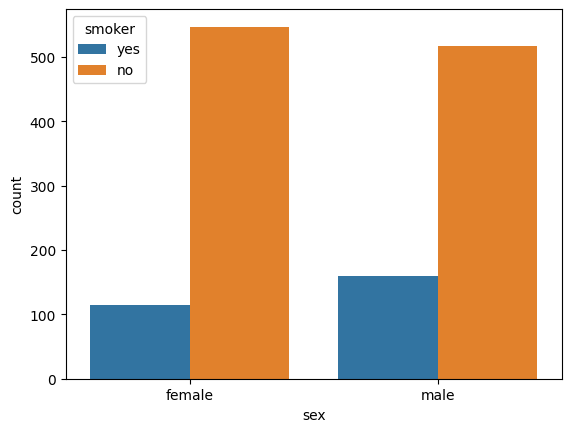

In [8]:
sns.countplot(data=df, x="sex", hue="smoker")
plt.show()

In [9]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [10]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


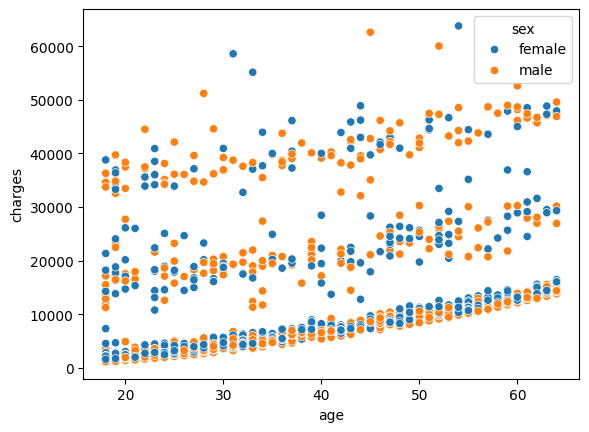

In [11]:
sns.scatterplot(data=df, x="age", y="charges", hue="sex")
plt.show()

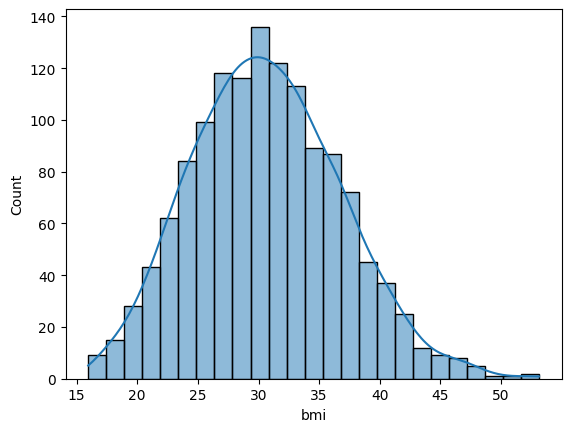

In [12]:
sns.histplot(data = df, x = "bmi", kde=True)
plt.show()

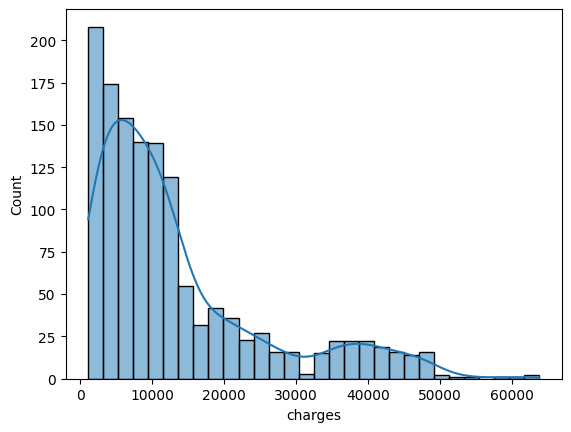

In [13]:
sns.histplot(data = df, x = "charges", kde=True)
plt.show()

In [14]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df.drop("Id", axis=1, inplace=True)

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [20]:
# one hot encoding --> region

In [21]:
X = df.drop("charges", axis = 1)
y = df["charges"]

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [25]:
categorical_cols = ["region"]

preprocessor = ColumnTransformer(transformers=[

        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
        
], remainder="passthrough")

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [26]:
from lightgbm import LGBMRegressor

In [27]:
model = LGBMRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 8
[LightGBM] [Info] Start training from score 13374.181390


c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [28]:
from sklearn.metrics import r2_score, mean_squared_error

In [29]:
print("R2 SCORE: ", r2_score(y_test, y_pred))
print("mse: ", mean_squared_error(y_test,y_pred))

R2 SCORE:  0.871843376594573
mse:  18458085.613847945


In [30]:
#hyperparameter tuning

In [31]:
param_grid = {
    
    "num_leaves": [31,50,70],
    "max_depth": [-1,5,10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100,300,1000],
    "min_child_samples": [10,20,30],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.5, 1.0],
    "reg_lambda": [0, 0.5, 1.0],

}

In [32]:
from sklearn.model_selection import RandomizedSearchCV

In [33]:
import warnings
warnings.filterwarnings("ignore")

In [34]:
random_search = RandomizedSearchCV(estimator=LGBMRegressor(verbosity = -1), param_distributions=param_grid, cv=5, verbose=0, random_state=15,
                                   scoring="neg_root_mean_squared_error", n_jobs=-1)

In [ ]:
random_search.fit(X_train, y_train)

In [ ]:
random_search.best_params_

{'subsample': 0.6,
 'reg_lambda': 1.0,
 'reg_alpha': 0.5,
 'num_leaves': 50,
 'n_estimators': 100,
 'min_child_samples': 30,
 'max_depth': -1,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [ ]:
y_pred = random_search.predict(X_test)

In [ ]:
print("R2 SCORE: ", r2_score(y_test, y_pred))
print("mse: ", mean_squared_error(y_test,y_pred))

R2 SCORE:  0.8858097014961821
mse:  16446549.93278381


In [ ]:
# let's try with a transformation on the dependent feature

In [ ]:
from scipy.stats import boxcox

In [ ]:
y_train_transformed, lambda_y = boxcox(y_train)

In [ ]:
model = LGBMRegressor()
model.fit(X_train, y_train_transformed)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
y_pred_transformed = model.predict(X_test)

In [ ]:
# Inverse -> BoxCox
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1 , 1 / lambda_)

In [ ]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [ ]:
print("R2 SCORE: ", r2_score(y_test, y_pred_original))
print("mse: ", mean_squared_error(y_test,y_pred_original))

R2 SCORE:  0.8925898035961266
mse:  15470028.378876308
